Feb 17th 2025  
Using the ring attractor network from Burak & Fiete (2012) to make some theoretical predictions about how much noise one might expect in a small ring network. 

Note that this is a simple minimal ring network. It does not have a mechanism for the bump location to be updated by angular velocity (though one is easy to add). But it should be good for order-of-magnitude type calculations for diffusivity and as a building block for more involved models.

The model parameters are number of neurons (N), membrane time constant (tau), recurrent connectivity matrix (W), f-I curve for single neurons (phi), and a background bias (b). We expect noise to depend on the number of spikes in the bump (i.e., roughly number of neurons times firing rate times bump width) and the noise model (i.e., Poisson spiking or something else).

In [1]:
import sys, os, glob
import datetime, time

import numpy as np
from numpy import linalg as nla
from numpy.random import default_rng

import matplotlib.pyplot as plt

gen_fns_dir = os.path.abspath('../shared')
sys.path.append(gen_fns_dir)

import ring_net_fns as rnf
import angle_fns_new as af

%matplotlib inline

curr_seed=int((time.time()%1)*(2**31))
print('Seed= {}'.format(curr_seed))
rng = default_rng(seed=curr_seed)

curr_date=datetime.datetime.now().strftime('%Y_%m_%d')+'_'

Seed= 1356090880


## Look at f-I curves and set up connectivity

These are the f-I curves used in Burak & Fiete. Note that they're effective f-I curves that (I think) account for background input etc. So rather than adding in a background input, the f-I curve is just shifted so that the neurons fire at negative input.

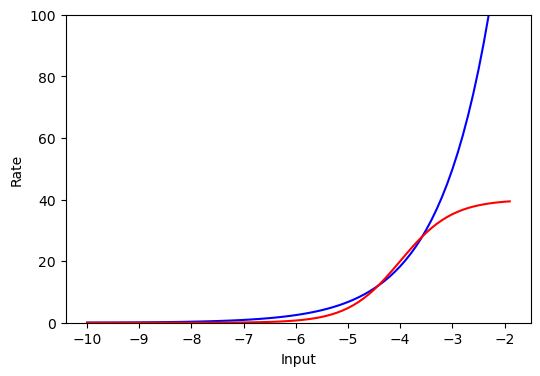

In [2]:
xx = np.arange(-10, -1.8, 0.1)

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(xx, rnf.exp_fi(xx), color='b', label='Exponential f-I')
ax.plot(xx, rnf.tanh_fi(xx), color='r', label='Tanh f-I')
ax.set_ylim([0,100])
ax.set_xlabel('Input')
ax.set_ylabel('Rate')
plt.show()

This is the connectivity profile in Burak & Fiete, which is the interaction strength between neurons separated by $\Delta \theta$. Note that angles are in radians since we use cosine functions to impose periodicity.

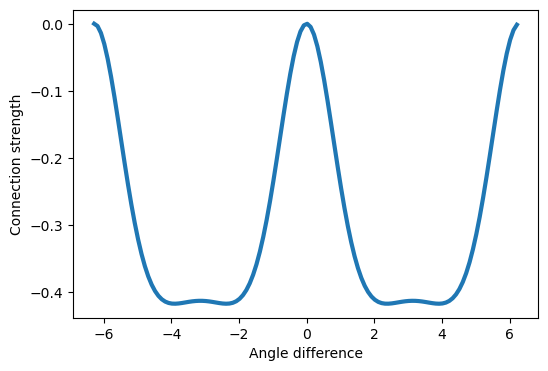

In [3]:
# We plot the connectivity profile over two cycles so that we can see periodicity
d_theta = np.arange(-2*np.pi, 2*np.pi, 0.1)

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(d_theta, rnf.bf_conn_profile(d_theta), lw=3)
ax.set(xlabel='Angle difference', ylabel='Connection strength')
# ax.set_xlim([-np.pi, np.pi])
plt.show()

## Now set up ring network. 

Major structural parameters are number of neurons, connectivity matrix and bias

0.0


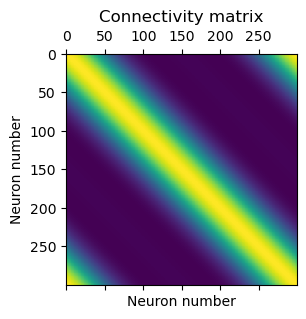

In [4]:
n_neurons = 300 # smaller than before
# Connectivity matrix, consisting of shifted copies of connectivity profile
pref_angles, W = rnf.get_W_and_pref_angles(n_neurons, rnf.bf_conn_profile)
fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.matshow(W)
ax.set(title='Connectivity matrix', xlabel='Neuron number', ylabel='Neuron number')
print(nla.norm(W - W.T))

# Bias vector. This will effectively set the firing rates
# bias = -3.5 * np.ones(n_neurons) # Used this for tanh
# bias = -2.25 * np.ones(n_neurons) # Used this for exp
bias = -2.5 * np.ones(n_neurons) # Slightly smaller firing rate

# Simulate network from some initial conditions for some time and visualize

In [5]:
# Initial conditions. Set it up so we get a bump somewhere in the middle
j0 = np.round(n_neurons*0.45).astype(int)
j1 = np.round(n_neurons*0.55).astype(int)
ics = np.zeros(n_neurons)
ics[j0:j1] = 1

t_max = 5.1

# Parameters for simulation are a combination of network parameters and time step info
params = {'dt' : 5e-4, 'tau' : 1e-2, 'ics' : ics, 'bias' : bias, 'fi' : rnf.exp_fi}
params['nSteps'] = int(t_max/params['dt'])

In [6]:
# Run simulation
tic = time.time()
s, rates = rnf.simulate_lnp_net(W, params)
t = np.arange(params['nSteps'])*params['dt']
print('Sim time ', time.time()-tic)

Sim time  0.49396395683288574


Plot the activity in various ways

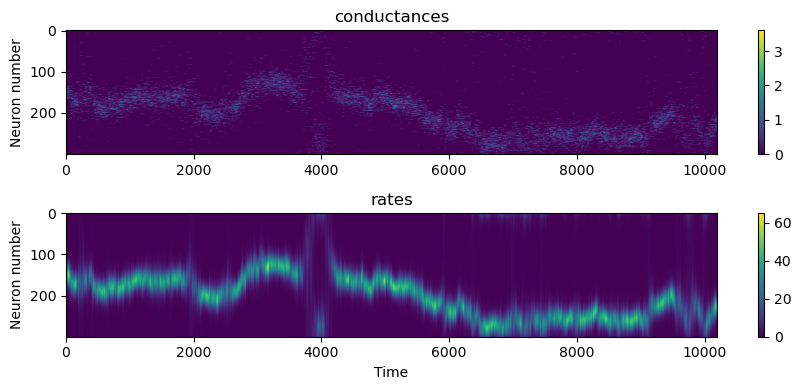

In [7]:
# Heatmaps of conductances and rates over time
fig, ax = plt.subplots(2,1,figsize=(9,4))
# ax[0].imshow(s.T, aspect='auto', vmin=0, vmax=1)
im1 = ax[0].imshow(s.T, aspect='auto')
ax[0].set(ylabel='Neuron number', title='conductances')
fig.colorbar(im1, ax=ax[0], orientation='vertical')  # Add colorbar

im2 = ax[1].imshow(rates.T, aspect='auto')
ax[1].set(xlabel='Time', ylabel='Neuron number', title='rates')
fig.colorbar(im2, ax=ax[1], orientation='vertical') 

plt.tight_layout()

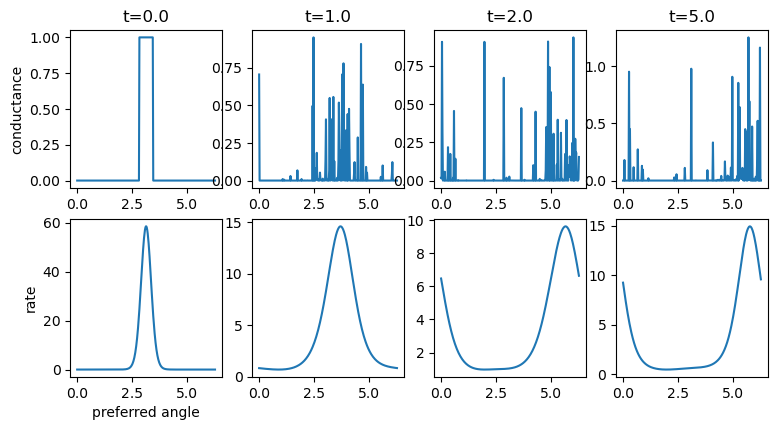

In [8]:
# Snapshots of rates and conductances at different moments in time. These are basically
# vertical slices of the heatmaps above, allowing us to see magnitudes a bit more clearly

time_points = np.array([0, 1, 2.0, 5])
time_idx = np.round(time_points/params['dt']).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(9,4.5))
for i, tid in enumerate(time_idx):
    axes[0,i].plot(pref_angles, s[tid])
    axes[1,i].plot(pref_angles, rates[tid])
    axes[0,i].set(title='t='+str(time_points[i]))
axes[0,0].set(ylabel='conductance');
axes[1,0].set(xlabel='preferred angle', ylabel='rate');

95th percentile is at  29.485666975556295


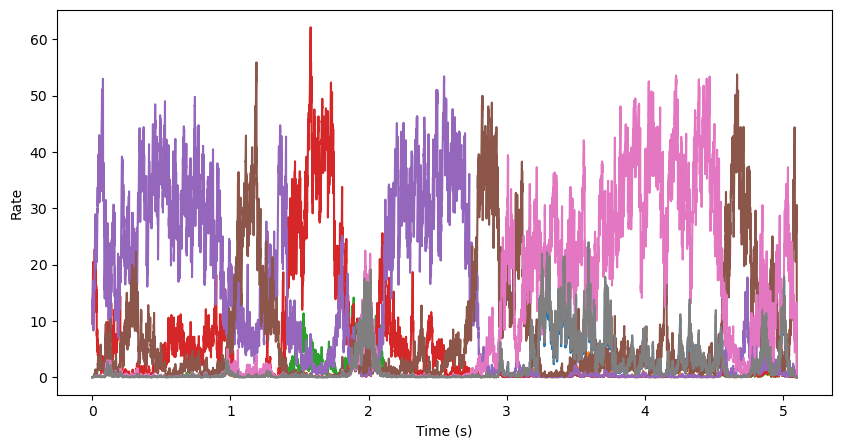

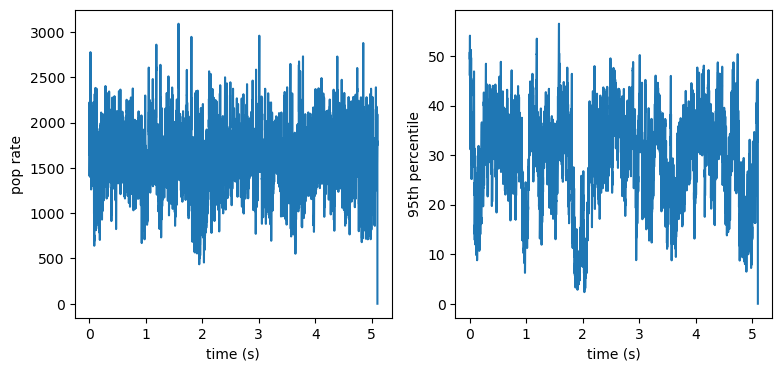

In [9]:
# Activity of selected neurons over time. Basically, horizontal slices from heatmap
sel_cells = np.round(np.linspace(0, n_neurons-1, 8)).astype(int) # neurons to plot
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
for i in sel_cells:
    ax.plot(t, rates[:,i])
ax.set(xlabel='Time (s)', ylabel='Rate')

# Plot the population (i.e., summed) firing rate and the 95th percentile of 
# firing rate over time. 95th percentile should be a decent proxy for bump height
high_perc = np.percentile(rates, 95, axis=1)
fig, ax = plt.subplots(1, 2,figsize=(9,4))
ax[0].plot(t, np.sum(rates, axis=1))
ax[1].plot(t, high_perc)
ax[0].set(xlabel='time (s)', ylabel='pop rate')
ax[1].set(xlabel='time (s)', ylabel='95th percentile')
print('95th percentile is at ', np.mean(high_perc))

Decode the encoded angle. 

In [10]:
max_rate_idx = np.argmax(rates, 1)
# Angle corresponding to max firing neuron
encoded_angle_max = pref_angles[max_rate_idx]
# Angle from population vector decoder
encoded_angle_pv = np.array([af.population_vector_decoder(r, pref_angles) for r in rates])

(3.4, 3.5)

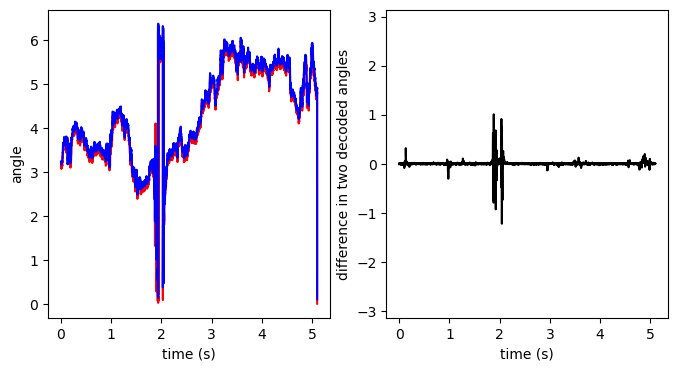

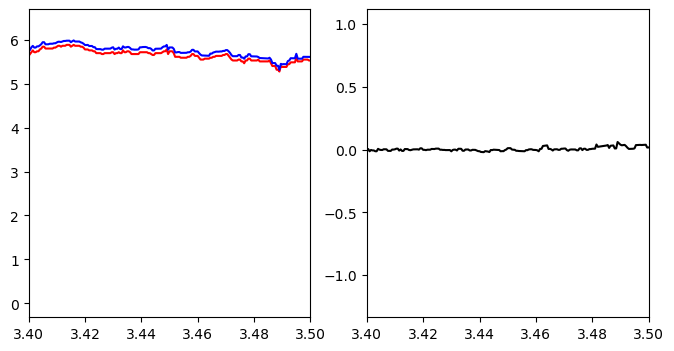

In [11]:
# Plot both angles
# Full range of time
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(t, encoded_angle_max, color='r', label='Max neuron')
ax[0].plot(t, encoded_angle_pv+1e-1, color='b', label='Pop vec decoded')
ax[0].set(xlabel='time (s)', ylabel='angle')
ax[1].plot(t, af.periodic_diff(encoded_angle_max, encoded_angle_pv), color='k', label='delta angle')
ax[1].set(xlabel='time (s)', ylabel='difference in two decoded angles')
ax[1].set_ylim([-np.pi, np.pi])

# Zoomed in on some subset of times and angles. Did this previously to look at moments when
# difference was large
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(t, encoded_angle_max, color='r', label='Max neuron')
ax[0].plot(t, encoded_angle_pv+1e-1, color='b', label='Pop vec decoded')
ax[0].set_xlim([3.4,3.5])
ax[1].plot(t, af.periodic_diff(encoded_angle_max, encoded_angle_pv), color='k', label='delta angle')
ax[1].set_xlim([3.4, 3.5])

# Simulate for longer and get some statistics  
Doing similar simulations as before, except now we are running for longer and trying to get some statistics that capture how the bump diffuses over time.

In [12]:
# Initial conditions. Set it up so we get a bump somewhere in the middle
j0 = np.round(n_neurons*0.45).astype(int)
j1 = np.round(n_neurons*0.55).astype(int)
ics = np.zeros(n_neurons)
ics[j0:j1] = 1

t_max = 200
params = {'dt' : 5e-4, 'tau' : 1e-2, 'ics' : ics, 'bias' : bias, 'fi' : rnf.exp_fi}
params['nSteps'] = int(t_max/params['dt'])

tic = time.time()
s, rates = rnf.simulate_lnp_net(W, params)
t = np.arange(params['nSteps'])*params['dt']
print('Sim time ', time.time()-tic)

# Decoding
max_rate_idx = np.argmax(rates, 1)
dec_angle_max = pref_angles[max_rate_idx]
dec_angle_pv = np.array([af.population_vector_decoder(r, pref_angles) for r in rates])

high_perc = np.percentile(rates, 95, axis=1)
print('95th percentile is at ', np.mean(high_perc))

Sim time  15.022923946380615
95th percentile is at  30.12637467472141


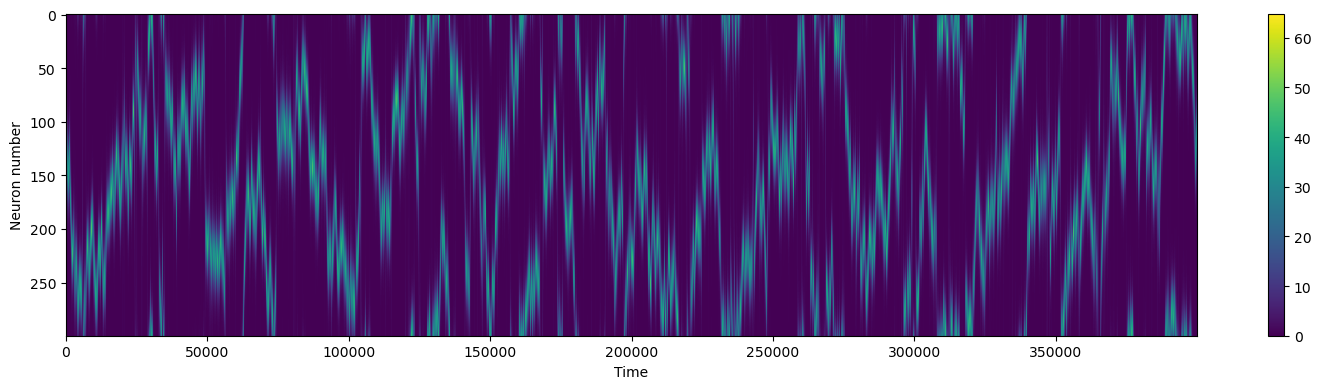

In [13]:
# Heatmap of rates
fig, ax = plt.subplots(1,1,figsize=(15,4))
# ax[0].imshow(s.T, aspect='auto', vmin=0, vmax=1)
im = ax.imshow(rates.T, aspect='auto')
ax.set(xlabel='Time', ylabel='Neuron number')
fig.colorbar(im, ax=ax, orientation='vertical') 

plt.tight_layout()

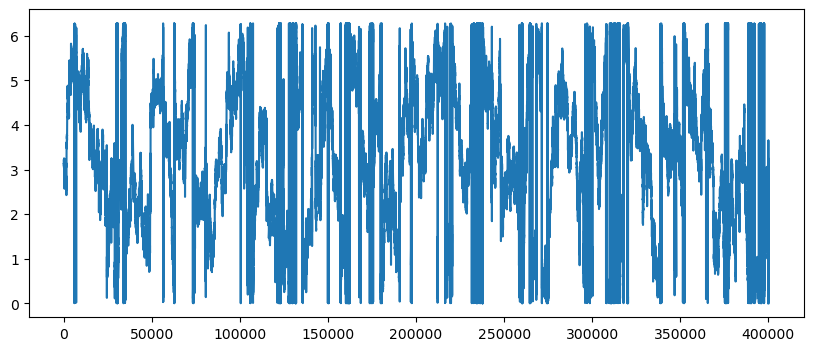

In [14]:
# Decoded angle over time
fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(dec_angle_pv)

In [15]:
# We now want to compute a diffusion curve at different spacings. 
# The diffusion curve capture how variance of bump position grows with time
taus, variances = af.compute_diffusion_curve(dec_angle_pv, max_tau=np.round(5.1/params['dt']).astype(int))

# Estimate diffusion constant, which is half the slope of this curve (so D and slope are redundant)
D, slope, intercept = af.compute_diffusion_constant(params['dt']*taus, np.array(variances))
print(D, slope, intercept)

# Note that for a variable with a finite range (like angle) curve is only expected to be 
# linear away from the bounds

0.5354323758926149 1.0708647517852299 0.5782597257301134


In [16]:
one_s_idx = np.round(1/params['dt']).astype(int) # Index of t=1
print(taus[one_s_idx]*params['dt']) # Just checking
print('Slope of variance curve ', 2*D)
print('Fitted standard deviation after 1s ', np.sqrt(2*D))
print('Measured standard deivation after 1s ', np.sqrt(variances[one_s_idx]))
print('Predicted standard deviation after 1s in degrees', np.sqrt(2*D)*180/np.pi)


1.0005
Slope of variance curve  1.0708647517852299
Fitted standard deviation after 1s  1.0348259524119163
Measured standard deivation after 1s  1.392487860083301
Predicted standard deviation after 1s in degrees 59.29115960380858


[Text(0.5, 0, 'time (s)'), Text(0, 0.5, 'standard deviation (rad)')]

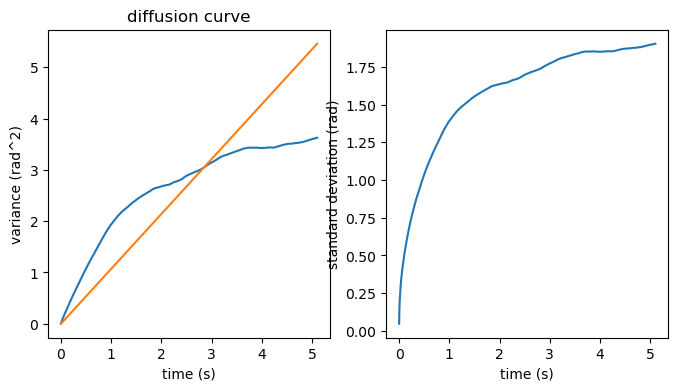

In [17]:
# Plot diffusion curve along with fits.
# Note that the linear fit is an underestimate for this particular parameter set,
# because we used a time range that is too big. Can scale time range to just fit
# the linear portion
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(taus*params['dt'], variances)
ax[0].plot(taus*params['dt'], 2*D*taus*params['dt'])
ax[0].set(xlabel='time (s)', ylabel='variance (rad^2)', title='diffusion curve')
ax[1].plot(taus*params['dt'], np.sqrt(variances))
ax[1].set(xlabel='time (s)', ylabel='standard deviation (rad)')

In [18]:
# Given this diffusion constant how long till standard deviation is 90 degrees or pi/2 radians
# desired_std = np.pi/2.
desired_std = 1.
desired_var = desired_std**2
print('Time taken to diffuse by standard deviation of 90 degrees ', desired_var/(2*D))

Time taken to diffuse by standard deviation of 90 degrees  0.9338247414838411
